# 🏠 Housing Price Regression — Machine Learning Final Project (Phase 1)

**Dataset:** Housing Prices Dataset  
**Source:** [Kaggle - Housing Prices Dataset](https://www.kaggle.com/datasets/arpitmourya/housing-prices-dataset)  
**Task:** Regression — Predict house prices based on various features  
**Models:** Linear Regression, Decision Tree Regressor, AdaBoost Regressor, Random Forest (Extra Credit)  

---

### Team Members
| # | Name | ID |
|---|------|----|
| 1 |  |  |
| 2 |  |  |
| 3 |  |  |
| 4 |  |  |
| 5 |  |  |
| 6 |  |  |

---
## 📦 1. Imports & Setup

In [1]:
# Core Libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import AdaBoostRegressor, RandomForestRegressor, GradientBoostingRegressor

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Style
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('✅ All libraries imported successfully!')
# SHAP for model interpretability (Extra Credit)
import shap


✅ All libraries imported successfully!


---
## 📥 2. Data Retrieval & Description

### Dataset Details
- **Dataset Name:** Housing Prices Dataset
- **Source:** Kaggle
- **Link:** https://www.kaggle.com/datasets/arpitmourya/housing-prices-dataset
- **Description:** This dataset contains information about 545 houses with 13 features including area, number of bedrooms/bathrooms, and various amenities. The target variable is the house price.

### Column Descriptions

| Column | Description | Type |
|--------|------------|------|
| `price` | Sale price of the house (in Rs.) | **Target** (Numerical) |
| `area` | Total area of the property in square feet | Numerical |
| `bedrooms` | Number of bedrooms | Numerical |
| `bathrooms` | Number of bathrooms | Numerical |
| `stories` | Number of stories (excluding basement) | Numerical |
| `mainroad` | Whether the house faces a main road (yes/no) | Categorical (Binary) |
| `guestroom` | Whether the house has a guest room (yes/no) | Categorical (Binary) |
| `basement` | Whether the house has a basement (yes/no) | Categorical (Binary) |
| `hotwaterheating` | Whether the house has hot water (yes/no) | Categorical (Binary) |
| `airconditioning` | Whether the house has air conditioning (yes/no) | Categorical (Binary) |
| `parking` | Number of parking spaces | Numerical |
| `prefarea` | Whether the house is in a preferred area (yes/no) | Categorical (Binary) |
| `furnishingstatus` | Furnishing status (furnished/semi-furnished/unfurnished) | Categorical (Ordinal) |

In [2]:
# Load the dataset
df = pd.read_csv('housing_prices.csv')

# First look at the data
print(f'📊 Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'\n📋 Column Names: {list(df.columns)}')
print(f'\n🎯 Target Variable (price) Statistics:')
print(f'  Mean:   {df["price"].mean():,.0f}')
print(f'  Median: {df["price"].median():,.0f}')
print(f'  Min:    {df["price"].min():,.0f}')
print(f'  Max:    {df["price"].max():,.0f}')
print(f'  Std:    {df["price"].std():,.0f}')

df.head(10)

📊 Dataset Shape: 545 rows × 13 columns

📋 Column Names: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

🎯 Target Variable (price) Statistics:
  Mean:   7,547,859
  Median: 7,318,432
  Min:    3,584,819
  Max:    13,882,876
  Std:    1,972,319


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,6093731,13799.0,6.0,1.0,1,yes,no,no,no,no,0,no,furnished
1,6911321,14082.0,5.0,1.0,1,yes,no,yes,no,no,1,yes,semi-furnished
2,11220867,13193.0,3.0,2.0,2,yes,no,no,no,no,3,yes,semi-furnished
3,6842131,4327.0,5.0,3.0,2,yes,no,no,no,yes,1,no,furnished
4,6012988,5989.0,6.0,2.0,2,yes,no,no,no,no,2,no,furnished
5,9557721,10319.0,4.0,2.0,4,yes,no,no,no,yes,2,no,unfurnished
6,7364527,15912.0,2.0,2.0,1,yes,no,no,no,no,0,no,unfurnished
7,4652750,3053.0,1.0,1.0,1,yes,no,no,no,yes,2,no,unfurnished
8,5905947,5711.0,5.0,2.0,1,yes,no,no,no,yes,0,no,furnished
9,5589378,5631.0,5.0,2.0,4,yes,no,yes,no,no,1,no,unfurnished


---
## 🔍 3. Data Exploration (EDA)

### 3.1 Dataset Structure & Info

In [3]:
# Dataset info
print('='*60)
print('📌 DATASET INFORMATION')
print('='*60)
df.info()

print('\n' + '='*60)
print('📌 DATA TYPES')
print('='*60)
print(df.dtypes)

📌 DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             545 non-null    int64  
 1   area              529 non-null    float64
 2   bedrooms          534 non-null    float64
 3   bathrooms         525 non-null    float64
 4   stories           545 non-null    int64  
 5   mainroad          545 non-null    object 
 6   guestroom         545 non-null    object 
 7   basement          545 non-null    object 
 8   hotwaterheating   545 non-null    object 
 9   airconditioning   545 non-null    object 
 10  parking           545 non-null    int64  
 11  prefarea          545 non-null    object 
 12  furnishingstatus  545 non-null    object 
dtypes: float64(3), int64(3), object(7)
memory usage: 55.5+ KB

📌 DATA TYPES
price                 int64
area                float64
bedrooms            float64
bathroo

### 3.2 Summary Statistics

In [4]:
# Summary statistics
print('📊 Summary Statistics for Numerical Features')
df.describe().round(2)

📊 Summary Statistics for Numerical Features


,price,area,bedrooms,bathrooms,stories,parking
count,545.00,529.00,534.00,525.00,545.00,545.00
mean,7547858.63,8761.46,3.54,1.98,2.31,1.30
std,1972319.42,4126.46,1.68,1.05,0.98,0.99
min,3584819.00,1718.00,1.00,1.00,1.00,0.00
25%,6036809.00,5170.00,2.00,1.00,2.00,0.00
50%,7318432.00,8776.00,4.00,2.00,2.00,1.00
75%,8857003.00,12286.00,5.00,3.00,3.00,2.00
max,13882876.00,16200.00,6.00,4.00,4.00,3.00


In [5]:
# Extended statistics: skewness and kurtosis
numerical_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
# Only use cols that exist and are numeric
num_df = df[numerical_cols].apply(pd.to_numeric, errors='coerce')

stats_df = pd.DataFrame({
    'Mean': num_df.mean(),
    'Median': num_df.median(),
    'Std': num_df.std(),
    'Skewness': num_df.skew(),
    'Kurtosis': num_df.kurtosis(),
    'Min': num_df.min(),
    'Max': num_df.max()
}).round(3)

print('📈 Extended Statistics (Including Skewness & Kurtosis)')
stats_df

📈 Extended Statistics (Including Skewness & Kurtosis)


,Mean,Median,Std,Skewness,Kurtosis,Min,Max
price,7547858.628,7318432.0,1972319.418,0.458,-0.225,3584819.0,13882876.0
area,8761.461,8776.0,4126.457,0.063,-1.167,1718.0,16200.0
bedrooms,3.536,4.0,1.683,-0.071,-1.208,1.0,6.0
bathrooms,1.977,2.0,1.046,0.728,-0.718,1.0,4.0
stories,2.314,2.0,0.985,0.243,-0.955,1.0,4.0
parking,1.301,1.0,0.988,0.081,-1.101,0.0,3.0


### 3.3 Missing Values, Duplicates & Data Quality

❓ MISSING VALUES ANALYSIS
           Missing Count  Missing %
area                  16       2.94
bedrooms              11       2.02
bathrooms             20       3.67

Total Missing Values: 47


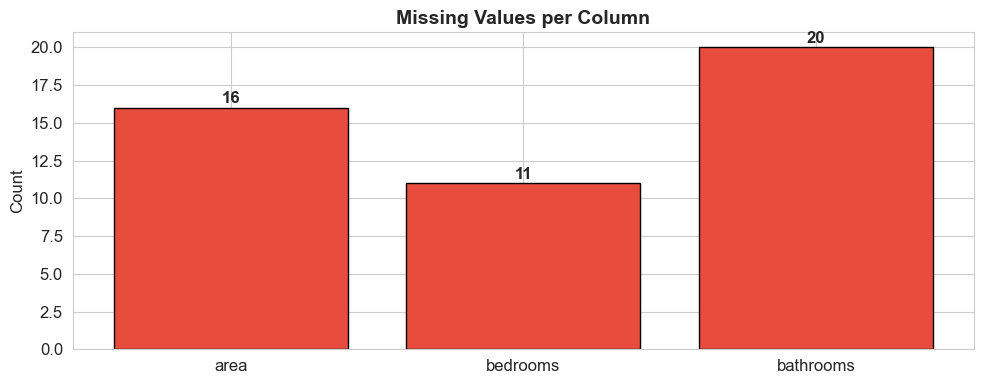


🔄 DUPLICATE ROWS
Number of duplicate rows: 0


In [6]:
# Missing values analysis
print('='*60)
print('❓ MISSING VALUES ANALYSIS')
print('='*60)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print(f'\nTotal Missing Values: {df.isnull().sum().sum()}')

# Visualize missing values
if df.isnull().sum().sum() > 0:
    plt.figure(figsize=(10, 4))
    missing_cols = missing[missing > 0]
    plt.bar(missing_cols.index, missing_cols.values, color='#e74c3c', edgecolor='black')
    plt.title('Missing Values per Column', fontsize=14, fontweight='bold')
    plt.ylabel('Count')
    for i, v in enumerate(missing_cols.values):
        plt.text(i, v + 0.3, str(v), ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

# Duplicates
print(f'\n' + '='*60)
print(f'🔄 DUPLICATE ROWS')
print('='*60)
dup_count = df.duplicated().sum()
print(f'Number of duplicate rows: {dup_count}')

### 3.4 Unique Values per Column

In [7]:
# Unique values for each column
print('🔢 Unique Values per Column:')
for col in df.columns:
    n_unique = df[col].nunique()
    if n_unique <= 10:
        print(f'  {col:20s} → {n_unique} unique values: {sorted(df[col].dropna().unique())}')
    else:
        print(f'  {col:20s} → {n_unique} unique values (range: {df[col].min()} - {df[col].max()})')

🔢 Unique Values per Column:
  price                → 545 unique values (range: 3584819 - 13882876)
  area                 → 522 unique values (range: 1718.0 - 16200.0)
  bedrooms             → 6 unique values: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0)]
  bathrooms            → 4 unique values: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
  stories              → 4 unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  mainroad             → 2 unique values: ['no', 'yes']
  guestroom            → 2 unique values: ['no', 'yes']
  basement             → 2 unique values: ['no', 'yes']
  hotwaterheating      → 2 unique values: ['no', 'yes']
  airconditioning      → 2 unique values: ['no', 'yes']
  parking              → 4 unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  prefarea             → 2 unique values: ['no', 'yes']
  furnishingstatus     → 3 unique values: ['furnis

### 3.5 Correlation Analysis

In [8]:
# Correlation matrix (numerical features only)
num_df_corr = df.select_dtypes(include=[np.number])
corr_matrix = num_df_corr.corr()

# Correlation with target
if 'price' in corr_matrix.columns:
    target_corr = corr_matrix['price'].drop('price').sort_values(ascending=False)
    print('🎯 Feature Correlation with Price:')
    print('='*50)
    for feat, corr in target_corr.items():
        direction = '⬆️ Positive' if corr > 0 else '⬇️ Negative'
        strength = 'Strong' if abs(corr) > 0.5 else 'Moderate' if abs(corr) > 0.3 else 'Weak'
        print(f'  {feat:20s}: {corr:+.4f} ({direction}, {strength})')

🎯 Feature Correlation with Price:
  area                : +0.7624 (⬆️ Positive, Strong)
  bedrooms            : +0.1459 (⬆️ Positive, Weak)
  bathrooms           : +0.1216 (⬆️ Positive, Weak)
  stories             : +0.0878 (⬆️ Positive, Weak)
  parking             : +0.0409 (⬆️ Positive, Weak)


---
## 🎨 4. Visualization

### 4.1 Target Distribution (Price)

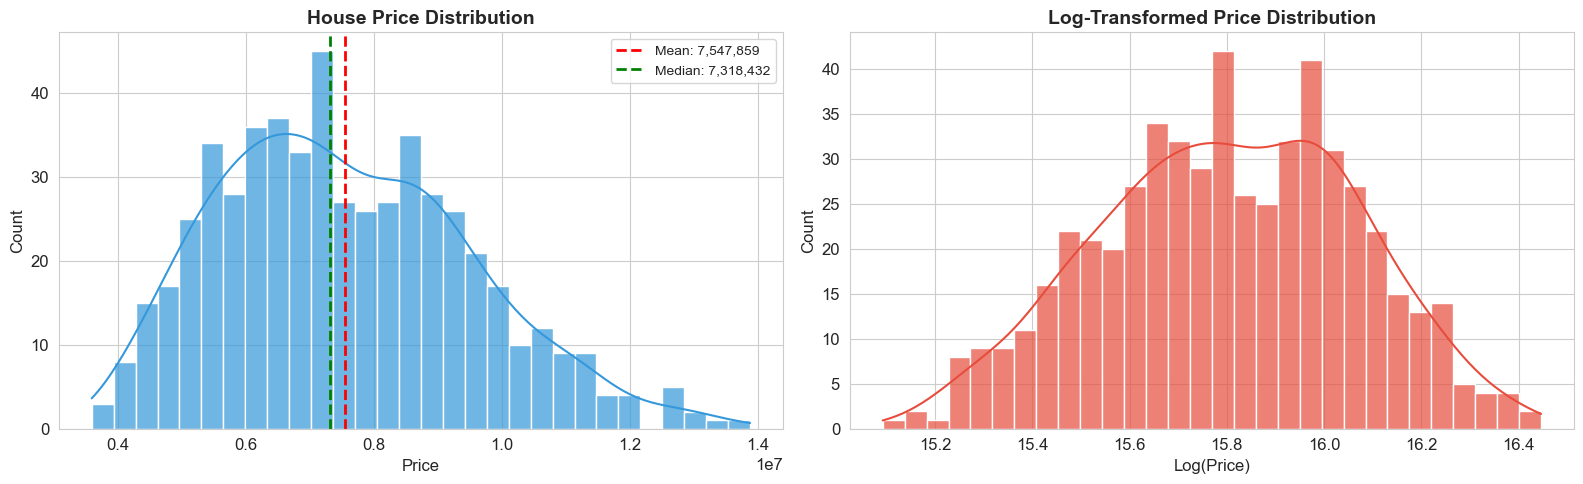

📊 Price Skewness: 0.458 (original) → -0.114 (log-transformed)


In [9]:
# Price distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
sns.histplot(df['price'], kde=True, ax=axes[0], color='#3498db', bins=30, alpha=0.7)
axes[0].axvline(df['price'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["price"].mean():,.0f}')
axes[0].axvline(df['price'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["price"].median():,.0f}')
axes[0].set_title('House Price Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price')
axes[0].legend(fontsize=10)

# Log-transformed
sns.histplot(np.log1p(df['price']), kde=True, ax=axes[1], color='#e74c3c', bins=30, alpha=0.7)
axes[1].set_title('Log-Transformed Price Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Log(Price)')

plt.tight_layout()
plt.show()

print(f'📊 Price Skewness: {df["price"].skew():.3f} (original) → {np.log1p(df["price"]).skew():.3f} (log-transformed)')

### 4.2 Numerical Feature Distributions

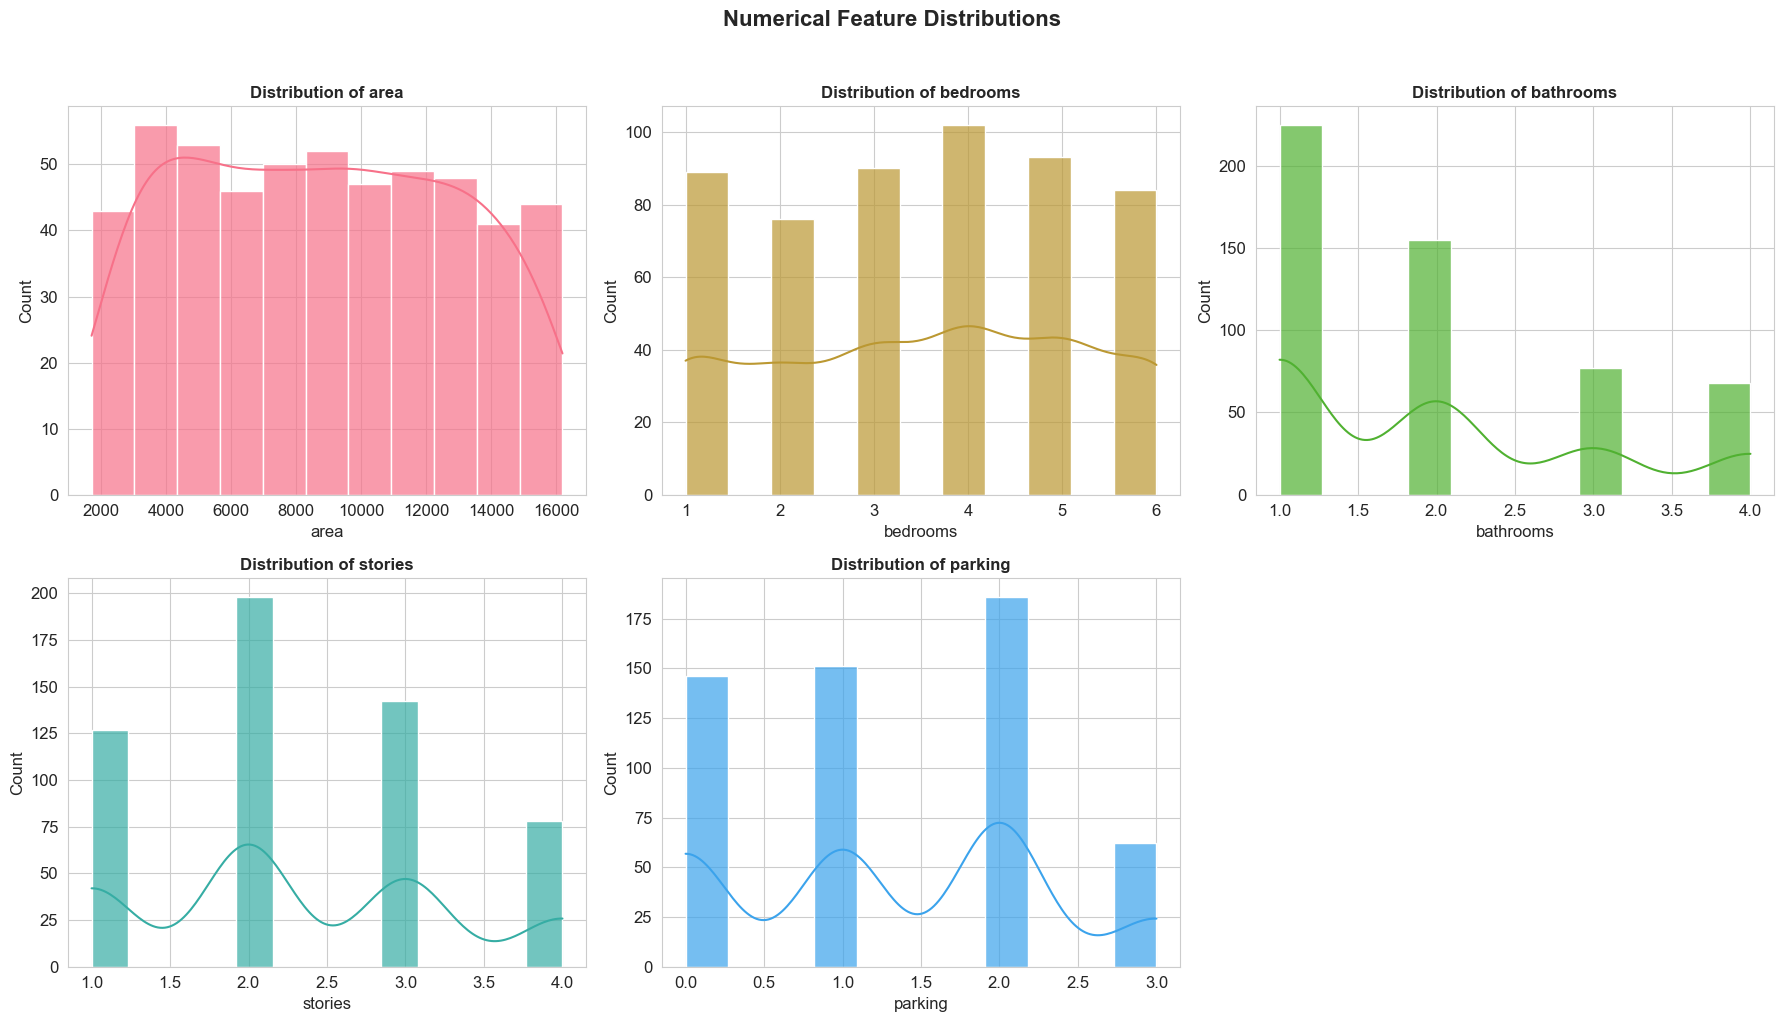

In [10]:
# Distribution plots for numerical features
num_features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(num_features):
    data = pd.to_numeric(df[col], errors='coerce').dropna()
    sns.histplot(data, kde=True, ax=axes[idx], color=sns.color_palette('husl', 6)[idx], alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')

axes[-1].set_visible(False)
plt.suptitle('Numerical Feature Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.3 Correlation Heatmap

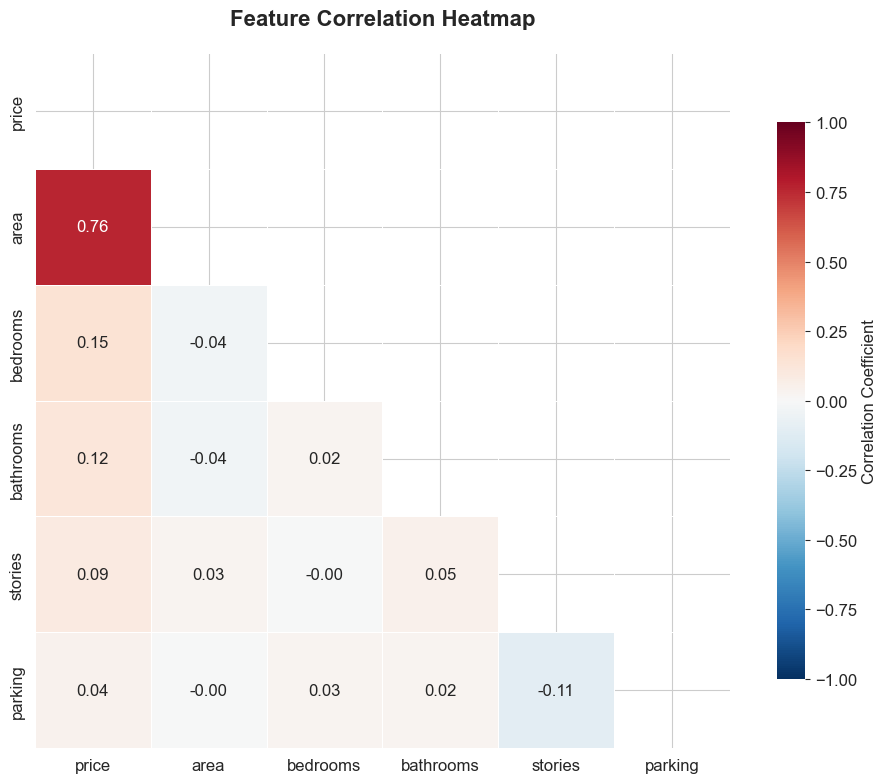

In [11]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'},
            vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### 4.4 Box Plots for Outlier Detection

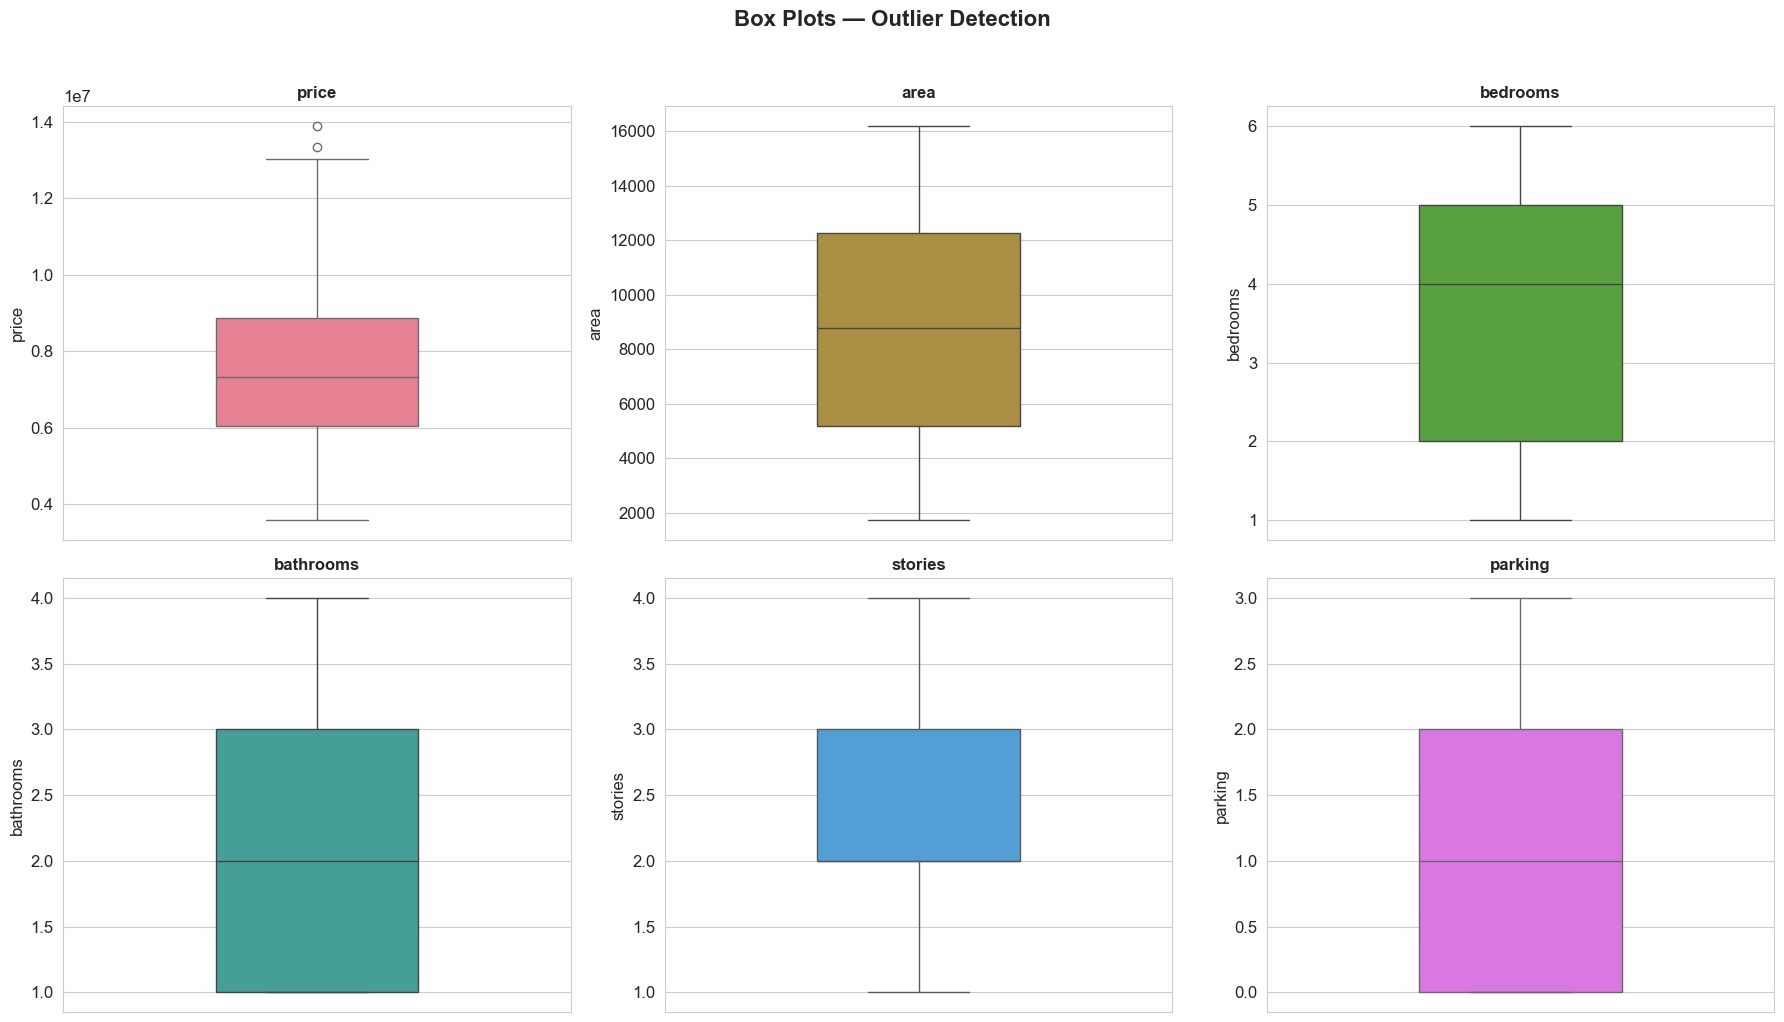

In [12]:
# Box plots for outlier detection
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

box_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
for idx, col in enumerate(box_cols):
    data = pd.to_numeric(df[col], errors='coerce').dropna()
    sns.boxplot(y=data, ax=axes[idx], color=sns.color_palette('husl', 6)[idx], width=0.4)
    axes[idx].set_title(f'{col}', fontsize=12, fontweight='bold')

plt.suptitle('Box Plots — Outlier Detection', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.5 Categorical Features vs Price

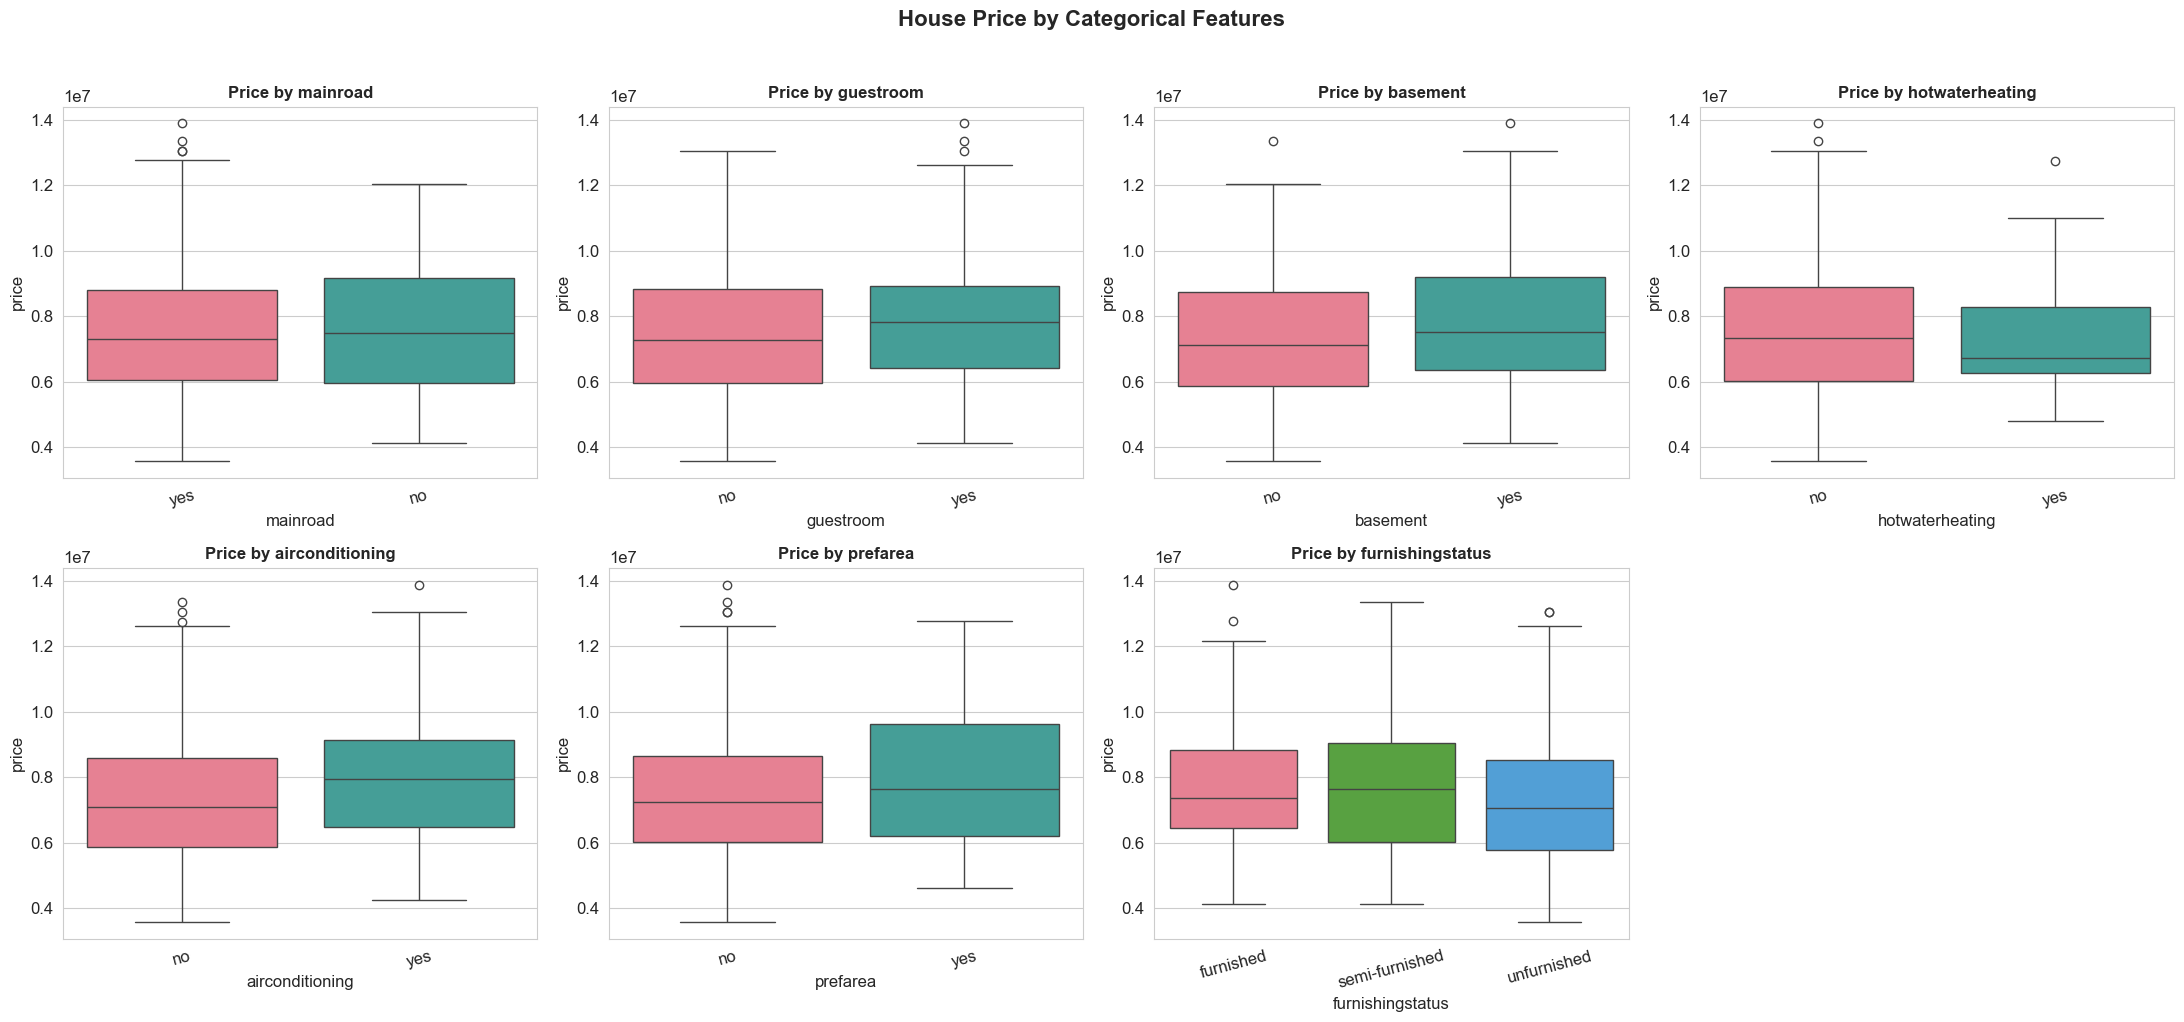

In [13]:
# Categorical features vs price
cat_features = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 
                'airconditioning', 'prefarea', 'furnishingstatus']

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for idx, col in enumerate(cat_features):
    sns.boxplot(data=df, x=col, y='price', ax=axes[idx], palette='husl')
    axes[idx].set_title(f'Price by {col}', fontsize=12, fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=15)

axes[-1].set_visible(False)
plt.suptitle('House Price by Categorical Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.6 Scatter Plots: Features vs Price

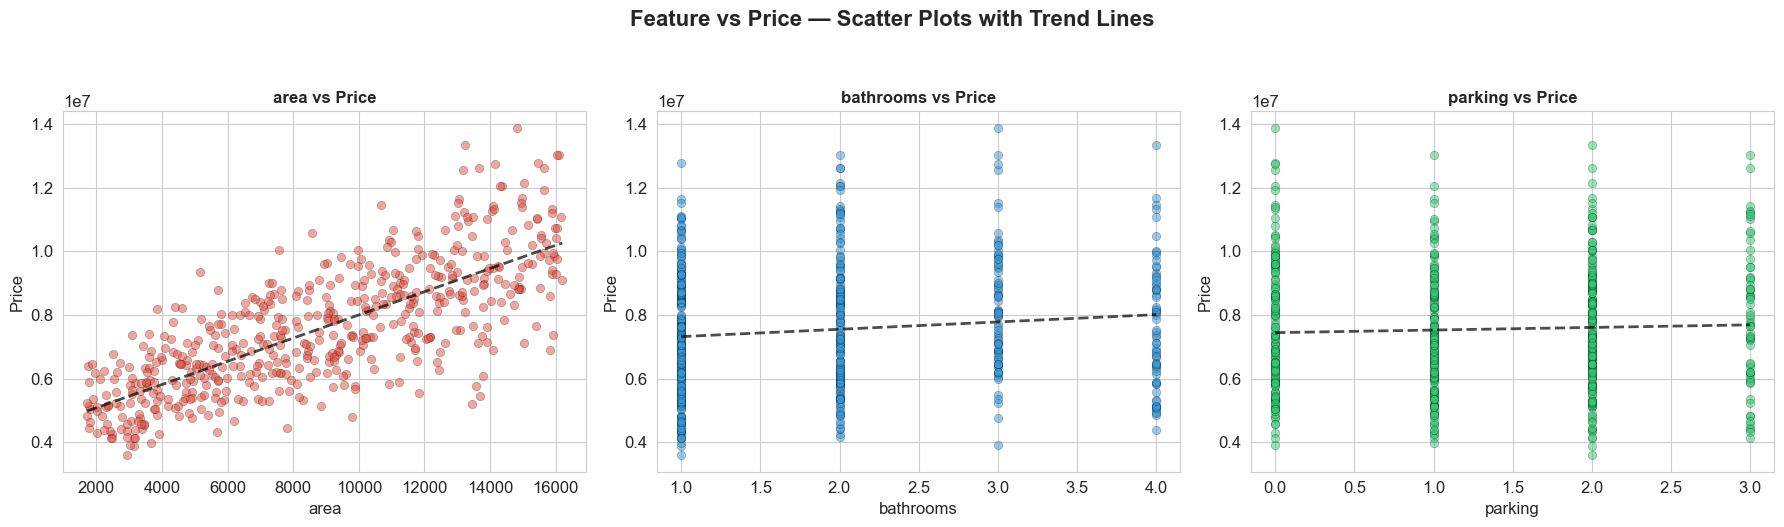

In [14]:
# Scatter plots for numerical features vs price
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
scatter_features = ['area', 'bathrooms', 'parking']
colors_scatter = ['#e74c3c', '#3498db', '#2ecc71']

for idx, col in enumerate(scatter_features):
    data = df[[col, 'price']].dropna()
    data[col] = pd.to_numeric(data[col], errors='coerce')
    data = data.dropna()
    axes[idx].scatter(data[col], data['price'], alpha=0.5, color=colors_scatter[idx], edgecolors='black', linewidth=0.3)
    # Add trend line
    z = np.polyfit(data[col], data['price'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(data[col].min(), data[col].max(), 100)
    axes[idx].plot(x_line, p(x_line), 'k--', linewidth=2, alpha=0.7)
    axes[idx].set_title(f'{col} vs Price', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Price')

plt.suptitle('Feature vs Price — Scatter Plots with Trend Lines', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

---
## 🔧 5. Data Preprocessing

### 5.1 Handle Missing Values

In [15]:
# Check missing values
print('❓ Missing Values Before Cleaning:')

# Convert empty strings to NaN first
df = df.replace('', np.nan)
df = df.replace(' ', np.nan)

missing_before = df.isnull().sum()
print(missing_before[missing_before > 0])
print(f'\nTotal missing: {df.isnull().sum().sum()}')

# Handle missing values
# For numerical columns: use median imputation
for col in ['area', 'bedrooms', 'bathrooms', 'parking', 'stories']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        if df[col].isnull().sum() > 0:
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)
            print(f'  ✅ Filled {col} missing values with median: {median_val}')

# For categorical columns: use mode imputation
for col in ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']:
    if col in df.columns and df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f'  ✅ Filled {col} missing values with mode: {mode_val}')

print(f'\n✅ Missing values after cleaning: {df.isnull().sum().sum()}')


❓ Missing Values Before Cleaning:
area         16
bedrooms     11
bathrooms    20
dtype: int64

Total missing: 47
  ✅ Filled area missing values with median: 8776.0
  ✅ Filled bedrooms missing values with median: 4.0
  ✅ Filled bathrooms missing values with median: 2.0

✅ Missing values after cleaning: 0


### 5.2 Outlier Detection & Treatment

In [16]:
# Outlier detection using IQR method
print('🔍 Outlier Detection (IQR Method):')
print('='*60)

outlier_cols = ['price', 'area']
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'  {col:12s}: {len(outliers):3d} outliers (range: [{lower:,.0f}, {upper:,.0f}])')

# Cap outliers
print('\n🔧 Capping Outliers:')
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = len(df[(df[col] < lower) | (df[col] > upper)])
    df[col] = df[col].clip(lower=lower, upper=upper)
    if before > 0:
        print(f'  ✅ {col}: Capped {before} outliers')

print('\n✅ Outlier treatment complete!')

🔍 Outlier Detection (IQR Method):
  price       :   2 outliers (range: [1,806,518, 13,087,294])
  area        :   0 outliers (range: [-5,087, 22,505])

🔧 Capping Outliers:
  ✅ price: Capped 2 outliers

✅ Outlier treatment complete!


### 5.3 Encoding Categorical Variables

In [17]:
# Encode categorical variables
print('🔄 Encoding Categorical Variables:')
print('='*60)

# Binary encoding for yes/no columns
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({'yes': 1, 'no': 0})
        print(f'  ✅ {col}: yes→1, no→0')

# One-hot encoding for furnishing status
if 'furnishingstatus' in df.columns:
    furn_dummies = pd.get_dummies(df['furnishingstatus'], prefix='furnishing', drop_first=True).astype(int)
    df = pd.concat([df, furn_dummies], axis=1)
    df.drop('furnishingstatus', axis=1, inplace=True)
    print(f'  ✅ furnishingstatus: One-hot encoded → {list(furn_dummies.columns)}')

# Ensure all columns are numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop any remaining rows with NaN after encoding
nan_count = df.isnull().sum().sum()
if nan_count > 0:
    print(f'\n⚠️ Found {nan_count} remaining NaN values after encoding, filling with column medians...')
    df = df.fillna(df.median())

print(f'\n📊 Dataset shape after encoding: {df.shape}')
print(f'✅ All columns numeric: {all(df.dtypes.apply(lambda x: x.kind in "iufb"))}')
df.head()


🔄 Encoding Categorical Variables:
  ✅ mainroad: yes→1, no→0
  ✅ guestroom: yes→1, no→0
  ✅ basement: yes→1, no→0
  ✅ hotwaterheating: yes→1, no→0
  ✅ airconditioning: yes→1, no→0
  ✅ prefarea: yes→1, no→0
  ✅ furnishingstatus: One-hot encoded → ['furnishing_semi-furnished', 'furnishing_unfurnished']

📊 Dataset shape after encoding: (545, 14)
✅ All columns numeric: True


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishing_semi-furnished,furnishing_unfurnished
0,6093731,13799.0,6.0,1.0,1,1,0,0,0,0,0,0,0,0
1,6911321,14082.0,5.0,1.0,1,1,0,1,0,0,1,1,1,0
2,11220867,13193.0,3.0,2.0,2,1,0,0,0,0,3,1,1,0
3,6842131,4327.0,5.0,3.0,2,1,0,0,0,1,1,0,0,0
4,6012988,5989.0,6.0,2.0,2,1,0,0,0,0,2,0,0,0


### 5.4 Feature Scaling & Train-Test Split

In [18]:
# Separate features and target
X = df.drop('price', axis=1)
y = df['price']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nFeature columns: {list(X.columns)}')

Features shape: (545, 13)
Target shape: (545,)

Feature columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishing_semi-furnished', 'furnishing_unfurnished']


In [19]:
# Train-Test Split FIRST (to avoid data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set:     {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)')

Training set: 436 samples (80%)
Test set:     109 samples (20%)


In [20]:
# Feature scaling AFTER split (no data leakage!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print('✅ Feature scaling complete (StandardScaler fitted on training data only)')
print('\n📊 Scaled Training Data Sample:')
X_train_scaled.head()

✅ Feature scaling complete (StandardScaler fitted on training data only)

📊 Scaled Training Data Sample:


,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishing_semi-furnished,furnishing_unfurnished
46,0.406051,0.286810,1.978407,0.673206,0.395599,-0.520708,1.300522,-0.182141,-0.720530,1.696354,-0.552620,1.366902,-0.724207
93,-0.259182,1.495012,-0.958887,-0.345953,0.395599,-0.520708,1.300522,-0.182141,-0.720530,0.698229,-0.552620,-0.731581,1.380821
335,1.521235,1.495012,0.999309,0.673206,0.395599,1.920461,1.300522,-0.182141,1.387867,-1.298020,-0.552620,-0.731581,-0.724207
412,1.045927,0.890911,-0.958887,-0.345953,0.395599,-0.520708,1.300522,-0.182141,1.387867,1.696354,1.809561,-0.731581,-0.724207
471,-0.613426,0.286810,0.999309,1.692365,0.395599,-0.520708,1.300522,-0.182141,1.387867,-1.298020,-0.552620,-0.731581,-0.724207


---
## 🤖 6. Modeling

We will train the following models:
1. **Linear Regression** (Required)
2. **Decision Tree Regressor** (Required)
3. **AdaBoost Regressor** (Required)
4. **Random Forest Regressor** (Extra Credit)
5. **Gradient Boosting Regressor** (Extra Credit)

### Helper Function for Evaluation

In [21]:
def evaluate_regression(model_name, y_true, y_pred, model=None, X_train=None, y_train_data=None):
    """Evaluate a regression model and return metrics."""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    # Adjusted R²
    n = len(y_true)
    p = X_test_scaled.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    
    # Cross-validation
    cv_text = 'N/A'
    if model is not None and X_train is not None and y_train_data is not None:
        cv_scores = cross_val_score(model, X_train, y_train_data, cv=5, scoring='r2')
        cv_text = f'{cv_scores.mean():.4f} ± {cv_scores.std():.4f}'
    
    print(f'\n{model_name} — Test Results:')
    print('='*50)
    print(f'  MAE:          {mae:,.2f}')
    print(f'  MSE:          {mse:,.2f}')
    print(f'  RMSE:         {rmse:,.2f}')
    print(f'  R² Score:     {r2:.4f}')
    print(f'  Adjusted R²:  {adj_r2:.4f}')
    print(f'  CV R² Score:  {cv_text}')
    
    return {
        'MAE': mae, 'MSE': mse, 'RMSE': rmse,
        'R²': r2, 'Adjusted R²': adj_r2, 'CV R² (Mean±Std)': cv_text
    }

### 6.1 Model 1: Linear Regression

In [22]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)
lr_metrics = evaluate_regression('📈 Linear Regression', y_test, lr_pred, lr_model, X_train_scaled, y_train)

# Show coefficients
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', ascending=False)

print(f'\n📊 Intercept: {lr_model.intercept_:,.2f}')
print('\nFeature Coefficients:')
display(coef_df)


📈 Linear Regression — Test Results:
  MAE:          920,529.07
  MSE:          1,264,711,525,280.68
  RMSE:         1,124,593.94
  R² Score:     0.6678
  Adjusted R²:  0.6224
  CV R² Score:  0.6372 ± 0.0650

📊 Intercept: 7,554,114.57

Feature Coefficients:


,Feature,Coefficient
0,area,1.482728e+06
1,bedrooms,3.688047e+05
2,bathrooms,3.277141e+05
10,prefarea,2.321959e+05
6,basement,2.189535e+05
9,parking,1.230891e+05
8,airconditioning,1.166124e+05
3,stories,7.853936e+04
5,guestroom,7.627355e+04
4,mainroad,6.559075e+04


#### Linear Regression Assumptions Check (Extra Credit)

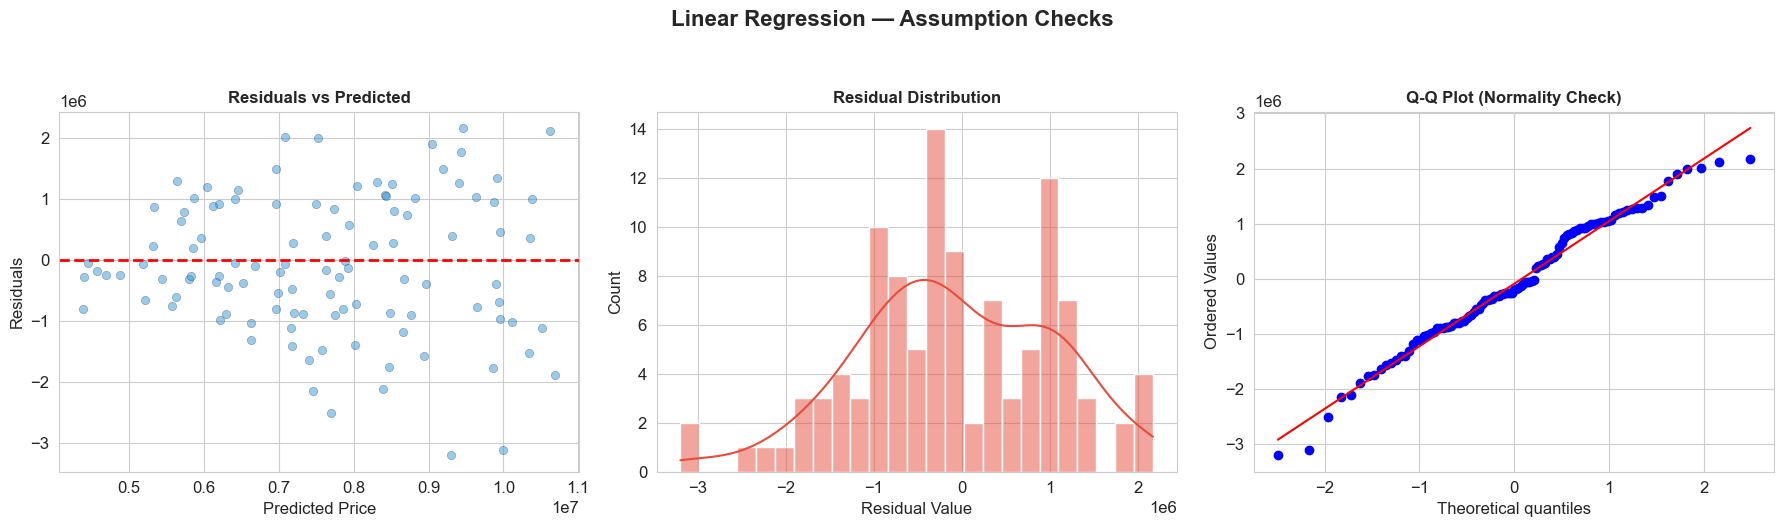

In [23]:
# Check Linear Regression assumptions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

residuals = y_test - lr_pred

# 1. Residuals vs Predicted
axes[0].scatter(lr_pred, residuals, alpha=0.5, color='#3498db', edgecolors='black', linewidth=0.3)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residuals')

# 2. Residual distribution
sns.histplot(residuals, kde=True, ax=axes[1], color='#e74c3c', bins=25)
axes[1].set_title('Residual Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Residual Value')

# 3. Q-Q Plot
from scipy import stats
stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold')

plt.suptitle('Linear Regression — Assumption Checks', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### 6.2 Model 2: Decision Tree Regressor

In [24]:
# Decision Tree with hyperparameter tuning via GridSearchCV
dt_params = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}

dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_params, cv=5, scoring='r2', n_jobs=-1, verbose=0
)

dt_grid.fit(X_train_scaled, y_train)
dt_best = dt_grid.best_estimator_

print('🌳 Decision Tree — Best Parameters:')
print(f'   {dt_grid.best_params_}')
print(f'   Best CV R² Score: {dt_grid.best_score_:.4f}')

dt_pred = dt_best.predict(X_test_scaled)
dt_metrics = evaluate_regression('🌳 Decision Tree Regressor', y_test, dt_pred, dt_best, X_train_scaled, y_train)

🌳 Decision Tree — Best Parameters:
   {'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 2}
   Best CV R² Score: 0.4992

🌳 Decision Tree Regressor — Test Results:
  MAE:          1,099,759.58
  MSE:          1,993,402,768,889.84
  RMSE:         1,411,879.16
  R² Score:     0.4764
  Adjusted R²:  0.4048
  CV R² Score:  0.4992 ± 0.0573


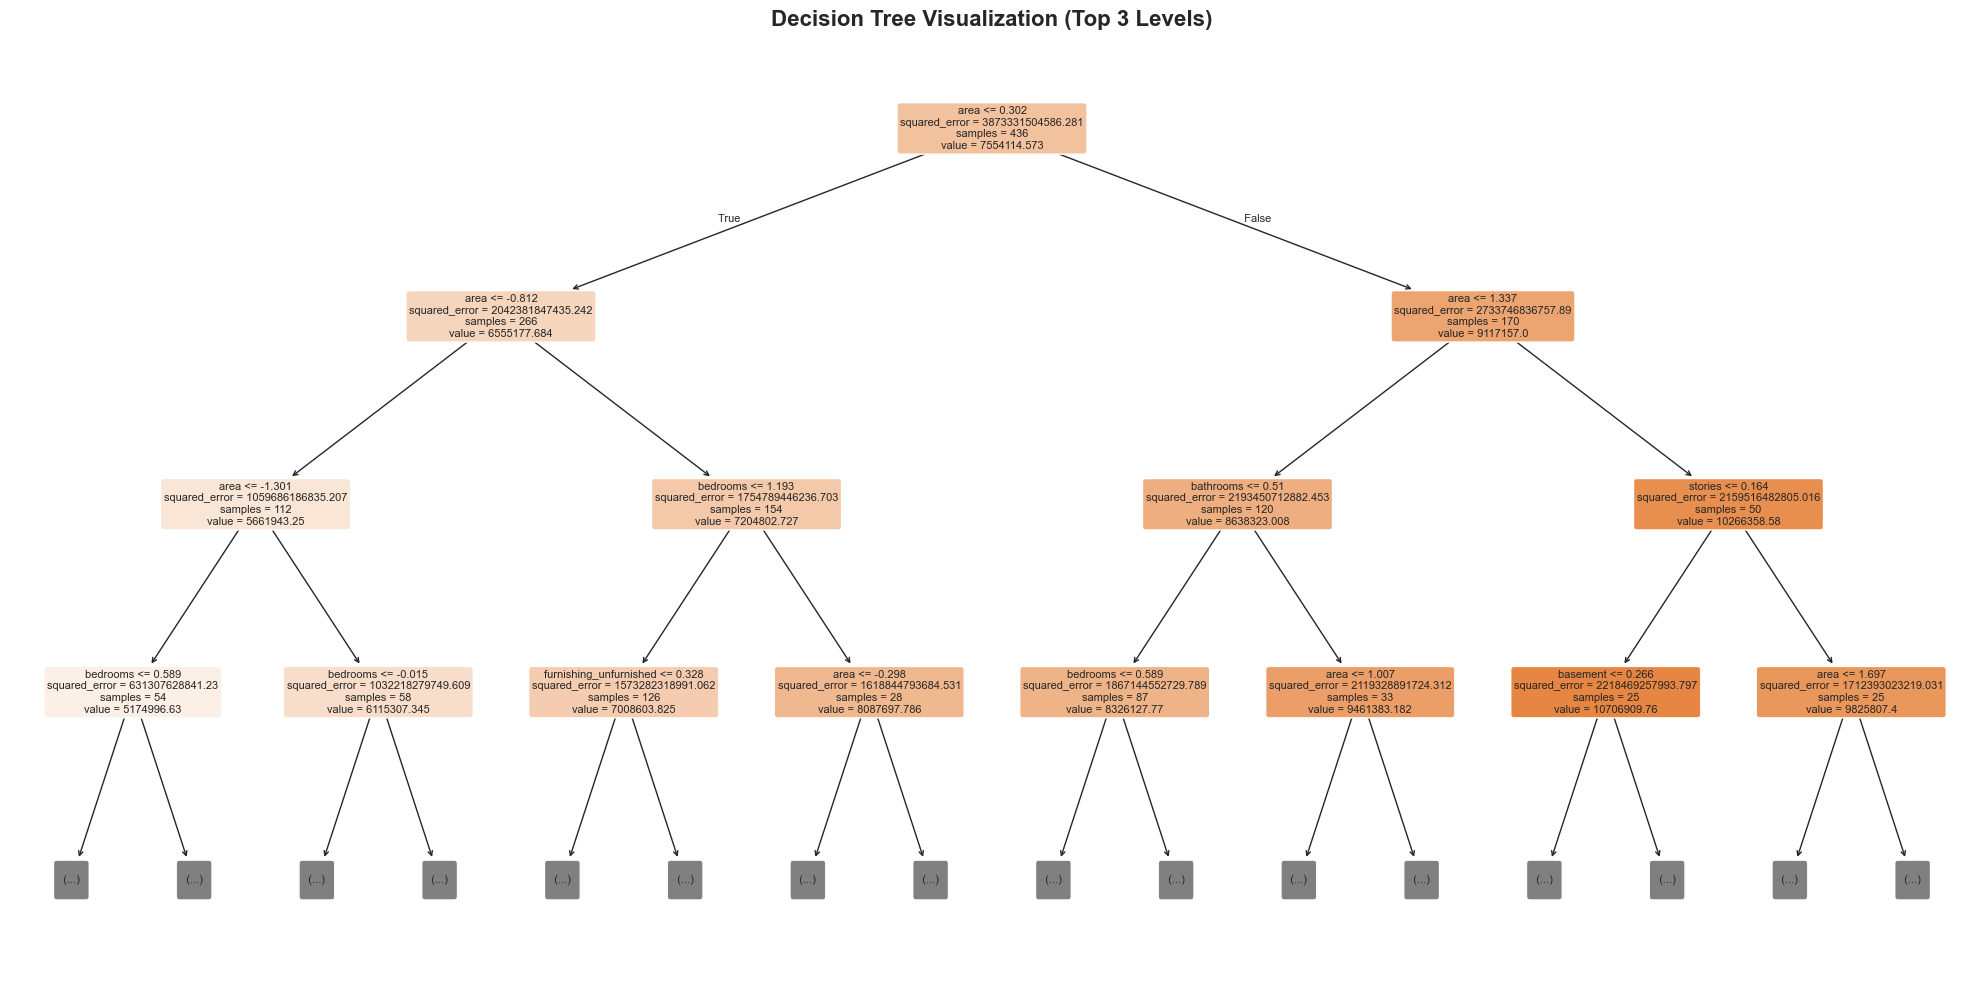

In [25]:
# Visualize the Decision Tree (top 3 levels)
plt.figure(figsize=(20, 10))
plot_tree(dt_best, feature_names=X.columns, filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title('Decision Tree Visualization (Top 3 Levels)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.3 Model 3: AdaBoost Regressor

In [26]:
# AdaBoost with hyperparameter tuning
ada_params = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0]
}

ada_grid = GridSearchCV(
    AdaBoostRegressor(random_state=42),
    ada_params, cv=5, scoring='r2', n_jobs=-1, verbose=0
)

ada_grid.fit(X_train_scaled, y_train)
ada_best = ada_grid.best_estimator_

print('🚀 AdaBoost — Best Parameters:')
print(f'   {ada_grid.best_params_}')
print(f'   Best CV R² Score: {ada_grid.best_score_:.4f}')

ada_pred = ada_best.predict(X_test_scaled)
ada_metrics = evaluate_regression('🚀 AdaBoost Regressor', y_test, ada_pred, ada_best, X_train_scaled, y_train)

🚀 AdaBoost — Best Parameters:
   {'learning_rate': 1.0, 'n_estimators': 200}
   Best CV R² Score: 0.5599

🚀 AdaBoost Regressor — Test Results:
  MAE:          1,091,769.33
  MSE:          1,786,952,218,009.22
  RMSE:         1,336,769.32
  R² Score:     0.5307
  Adjusted R²:  0.4664
  CV R² Score:  0.5599 ± 0.0791


### 6.4 Model 4: Random Forest Regressor (Extra Credit)

In [27]:
# Random Forest with hyperparameter tuning
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params, cv=5, scoring='r2', n_jobs=-1, verbose=0
)

rf_grid.fit(X_train_scaled, y_train)
rf_best = rf_grid.best_estimator_

print('🌲 Random Forest — Best Parameters:')
print(f'   {rf_grid.best_params_}')
print(f'   Best CV R² Score: {rf_grid.best_score_:.4f}')

rf_pred = rf_best.predict(X_test_scaled)
rf_metrics = evaluate_regression('🌲 Random Forest Regressor', y_test, rf_pred, rf_best, X_train_scaled, y_train)

🌲 Random Forest — Best Parameters:
   {'max_depth': 15, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 300}
   Best CV R² Score: 0.5909

🌲 Random Forest Regressor — Test Results:
  MAE:          1,002,048.52
  MSE:          1,567,822,397,008.62
  RMSE:         1,252,127.15
  R² Score:     0.5882
  Adjusted R²:  0.5319
  CV R² Score:  0.5909 ± 0.0705


### 6.5 Model 5: Gradient Boosting Regressor (Extra Credit)

In [28]:
# Gradient Boosting
gb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_params, cv=5, scoring='r2', n_jobs=-1, verbose=0
)

gb_grid.fit(X_train_scaled, y_train)
gb_best = gb_grid.best_estimator_

print('🔥 Grad.ient Boosting — Best Parameters:')
print(f'   {gb_grid.best_params_}')
print(f'   Best CV R² Score: {gb_grid.best_score_:.4f}')

gb_pred = gb_best.predict(X_test_scaled)
gb_metrics = evaluate_regression('🔥 Gradient Boosting Regressor', y_test, gb_pred, gb_best, X_train_scaled, y_train)

🔥 Grad.ient Boosting — Best Parameters:
   {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
   Best CV R² Score: 0.5994

🔥 Gradient Boosting Regressor — Test Results:
  MAE:          943,377.26
  MSE:          1,406,458,839,825.84
  RMSE:         1,185,942.17
  R² Score:     0.6306
  Adjusted R²:  0.5801
  CV R² Score:  0.5994 ± 0.0851


---
## 📊 7. Model Evaluation & Comparison

### 7.1 Model Comparison Table

In [29]:
# Comprehensive model comparison
all_metrics = {
    'Linear Regression': lr_metrics,
    'Decision Tree': dt_metrics,
    'AdaBoost': ada_metrics,
    'Random Forest': rf_metrics,
    'Gradient Boosting': gb_metrics
}

comparison_df = pd.DataFrame(all_metrics).T

print('🏆 MODEL COMPARISON TABLE')
print('='*90)
display(comparison_df)

# Find the best model
best_model = comparison_df['R²'].astype(float).idxmax()
best_r2 = comparison_df['R²'].astype(float).max()
print(f'\n🥇 Best Model: {best_model} (R² Score: {best_r2:.4f})')

🏆 MODEL COMPARISON TABLE


,MAE,MSE,RMSE,R²,Adjusted R²,CV R² (Mean±Std)
Linear Regression,920529.067304,1264711525280.681885,1124593.937953,0.667829,0.622374,0.6372 ± 0.0650
Decision Tree,1099759.581971,1993402768889.842041,1411879.162283,0.476442,0.404797,0.4992 ± 0.0573
AdaBoost,1091769.334832,1786952218009.221436,1336769.321165,0.530665,0.466441,0.5599 ± 0.0791
Random Forest,1002048.519566,1567822397008.623779,1252127.148898,0.588219,0.53187,0.5909 ± 0.0705
Gradient Boosting,943377.257154,1406458839825.842285,1185942.173896,0.6306,0.580051,0.5994 ± 0.0851



🥇 Best Model: Linear Regression (R² Score: 0.6678)


### 7.2 Actual vs Predicted Plots

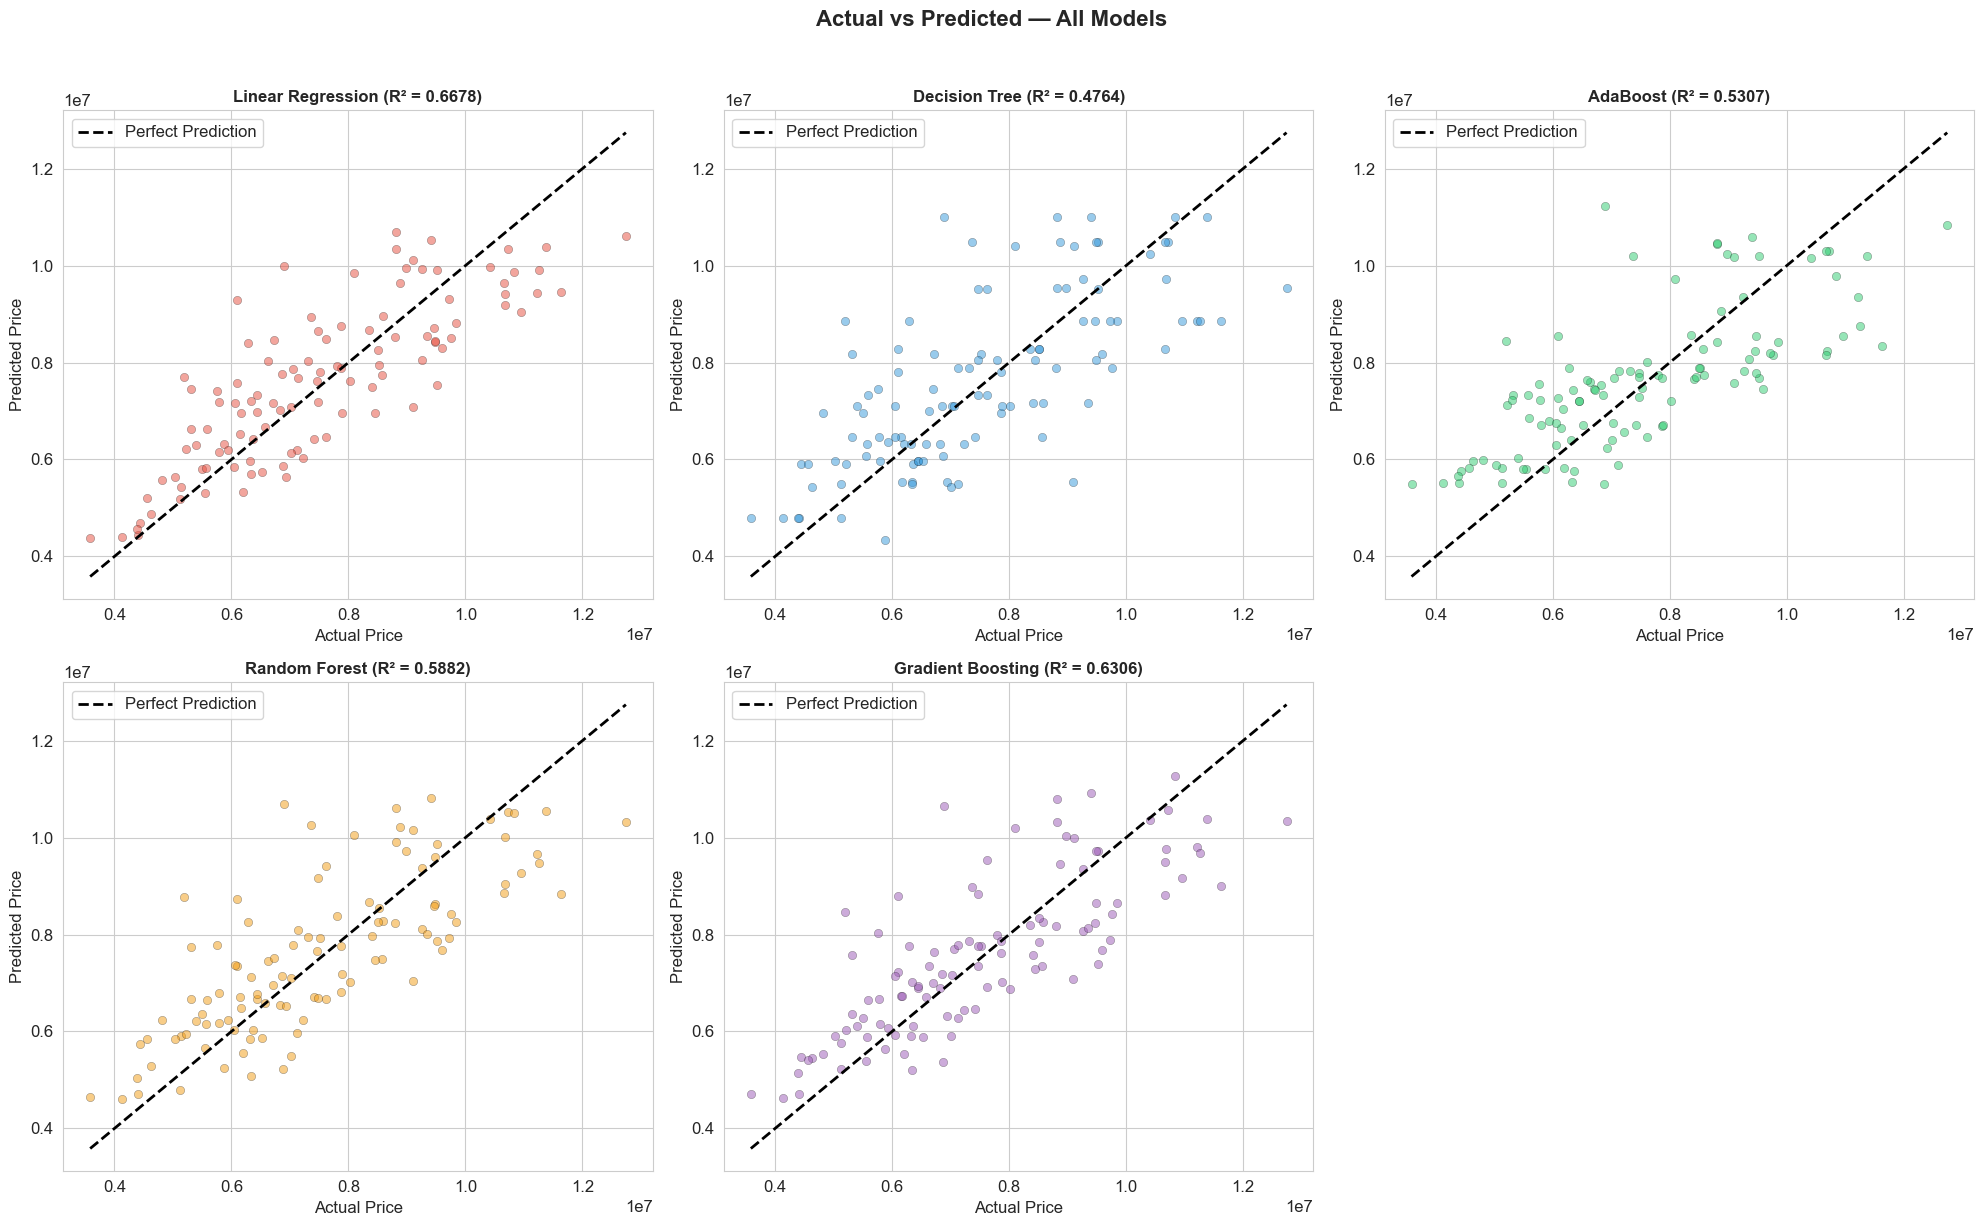

In [30]:
# Actual vs Predicted for all models
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

all_preds = {
    'Linear Regression': lr_pred,
    'Decision Tree': dt_pred,
    'AdaBoost': ada_pred,
    'Random Forest': rf_pred,
    'Gradient Boosting': gb_pred
}

colors_models = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

for idx, (name, preds) in enumerate(all_preds.items()):
    ax = axes[idx]
    ax.scatter(y_test, preds, alpha=0.5, color=colors_models[idx], edgecolors='black', linewidth=0.3)
    
    # Perfect prediction line
    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect Prediction')
    
    r2 = r2_score(y_test, preds)
    ax.set_title(f'{name} (R² = {r2:.4f})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.legend()

axes[-1].set_visible(False)
plt.suptitle('Actual vs Predicted — All Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 7.3 Residual Plots

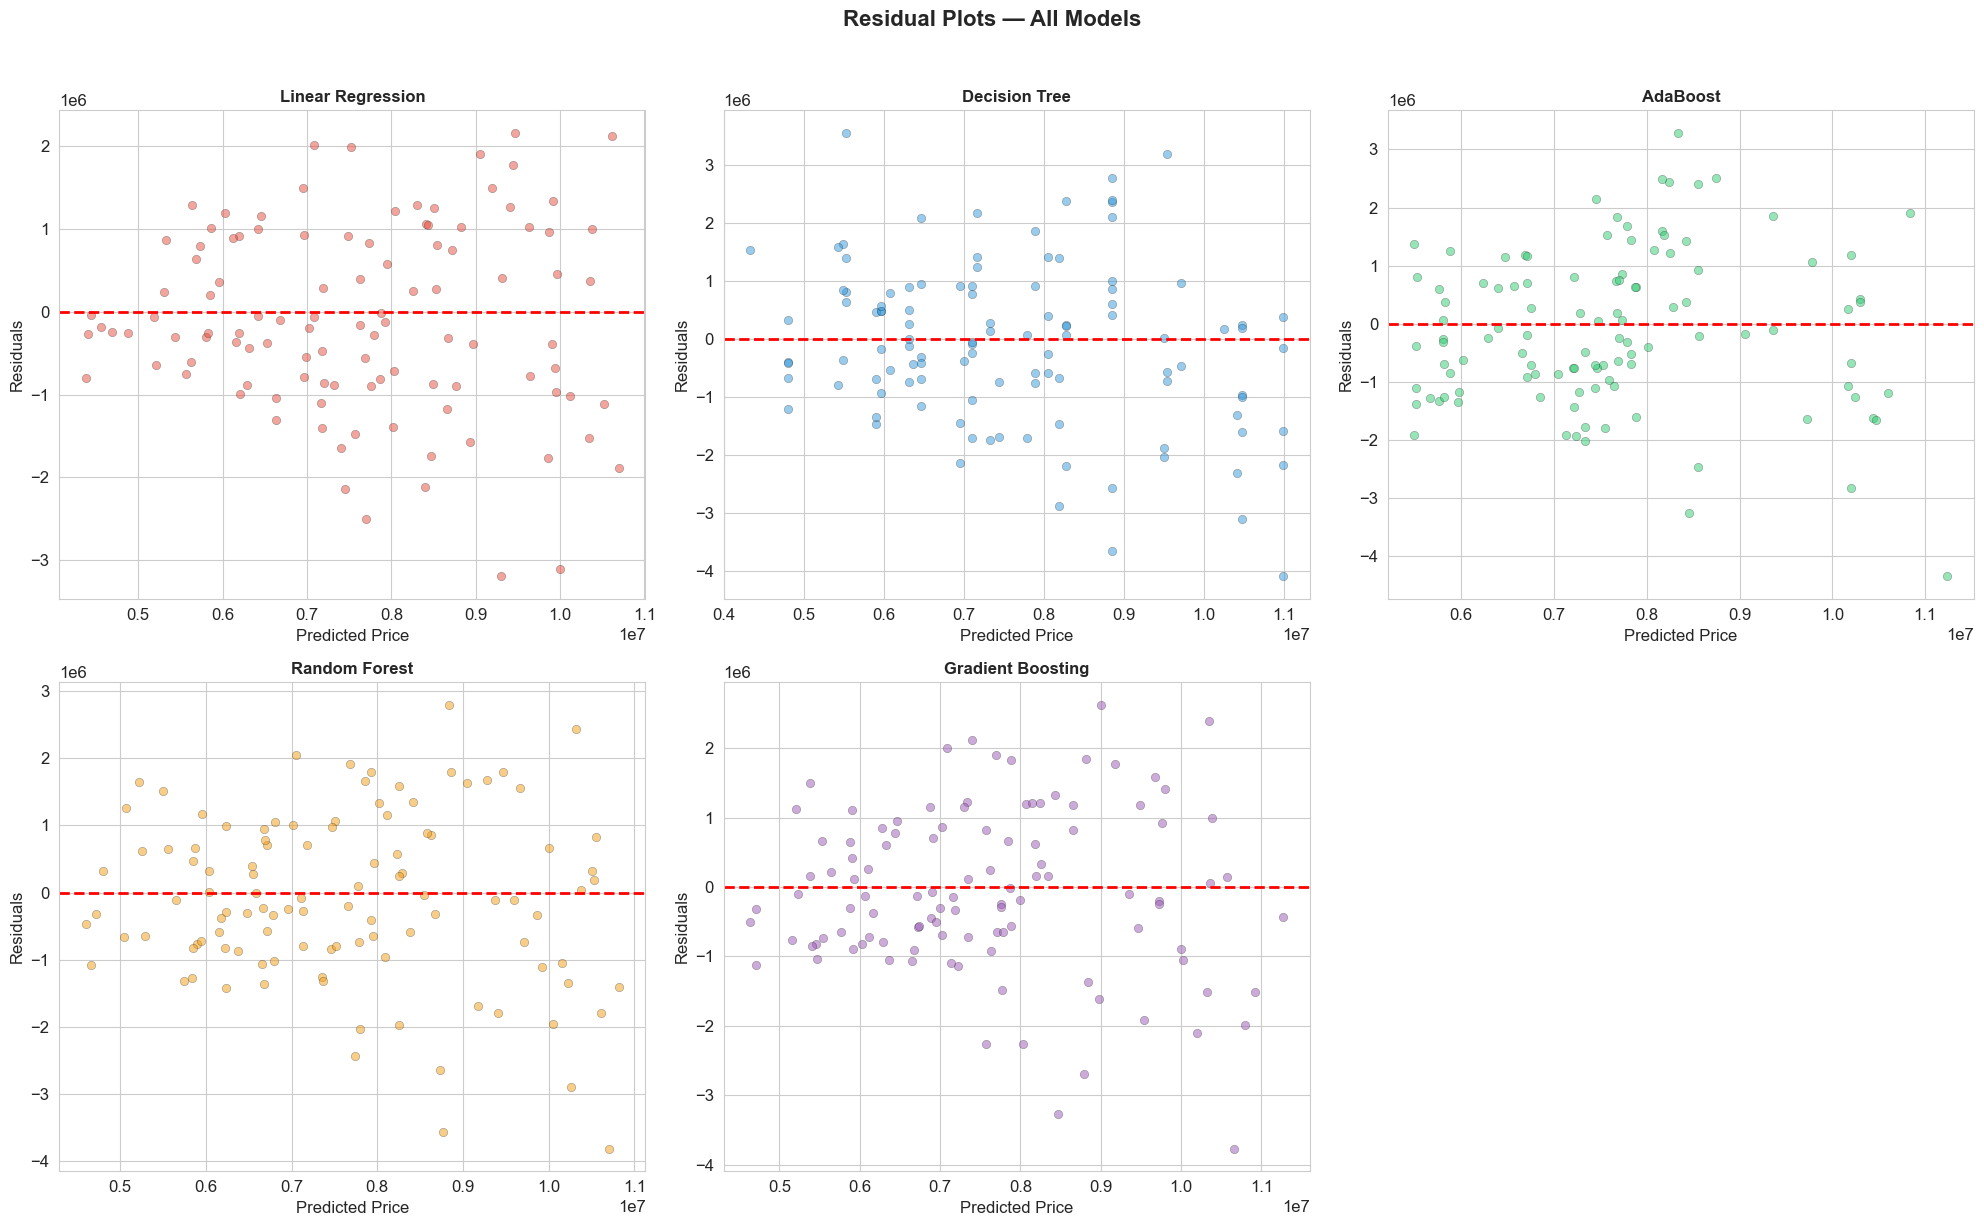

In [31]:
# Residual plots for all models
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, (name, preds) in enumerate(all_preds.items()):
    ax = axes[idx]
    residuals = y_test - preds
    ax.scatter(preds, residuals, alpha=0.5, color=colors_models[idx], edgecolors='black', linewidth=0.3)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Price')
    ax.set_ylabel('Residuals')

axes[-1].set_visible(False)
plt.suptitle('Residual Plots — All Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 7.4 Feature Importance

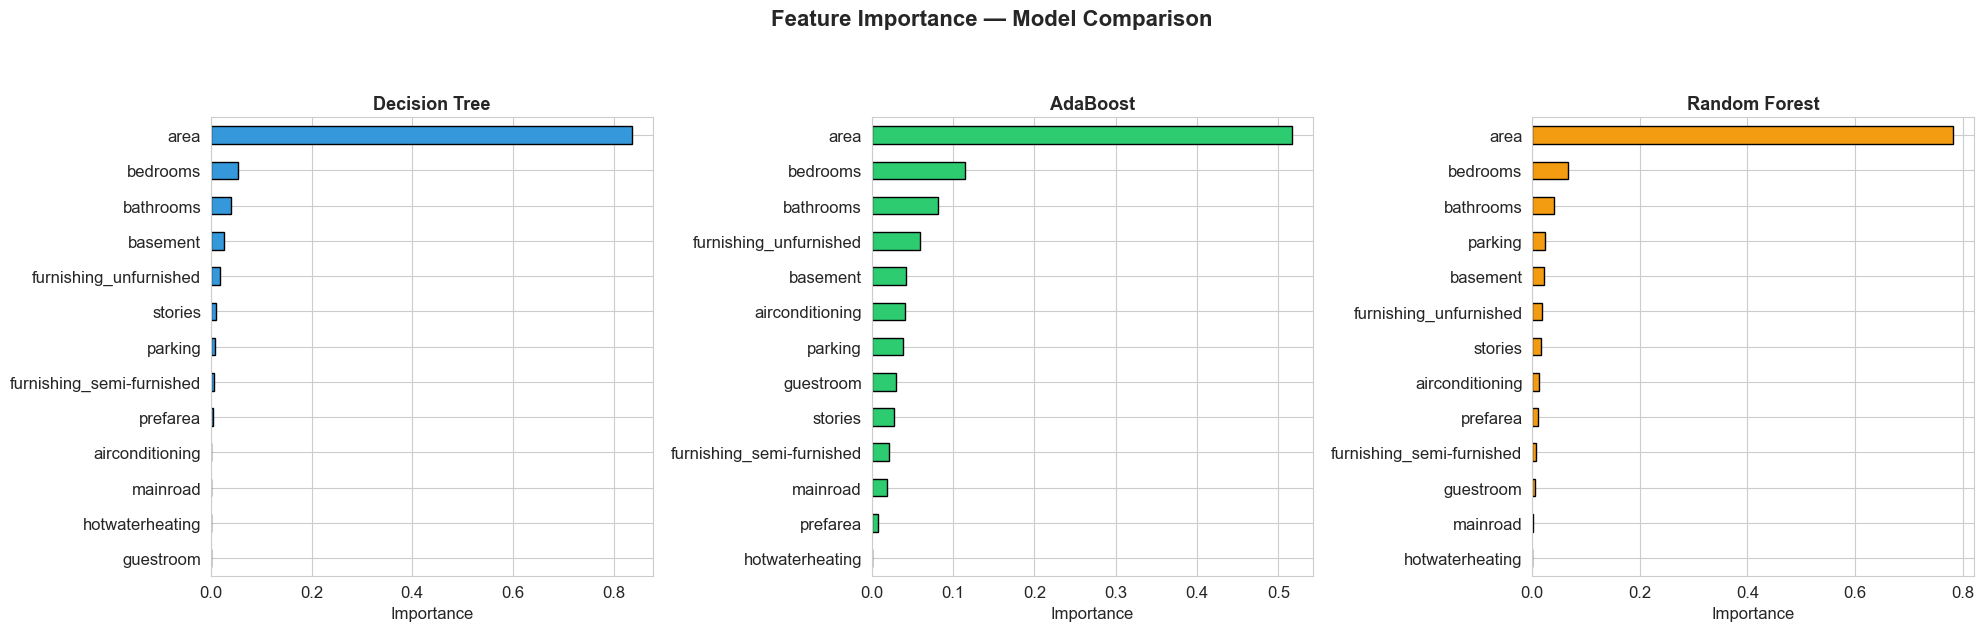

In [32]:
# Feature importance comparison (tree-based models)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

tree_models = {
    'Decision Tree': dt_best,
    'AdaBoost': ada_best,
    'Random Forest': rf_best
}

for idx, (name, model) in enumerate(tree_models.items()):
    importances = pd.Series(model.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=True)
    importances.plot(kind='barh', ax=axes[idx], color=colors_models[idx+1], edgecolor='black')
    axes[idx].set_title(f'{name}', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Importance')

plt.suptitle('Feature Importance — Model Comparison', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### 7.5 Metrics Comparison Bar Chart

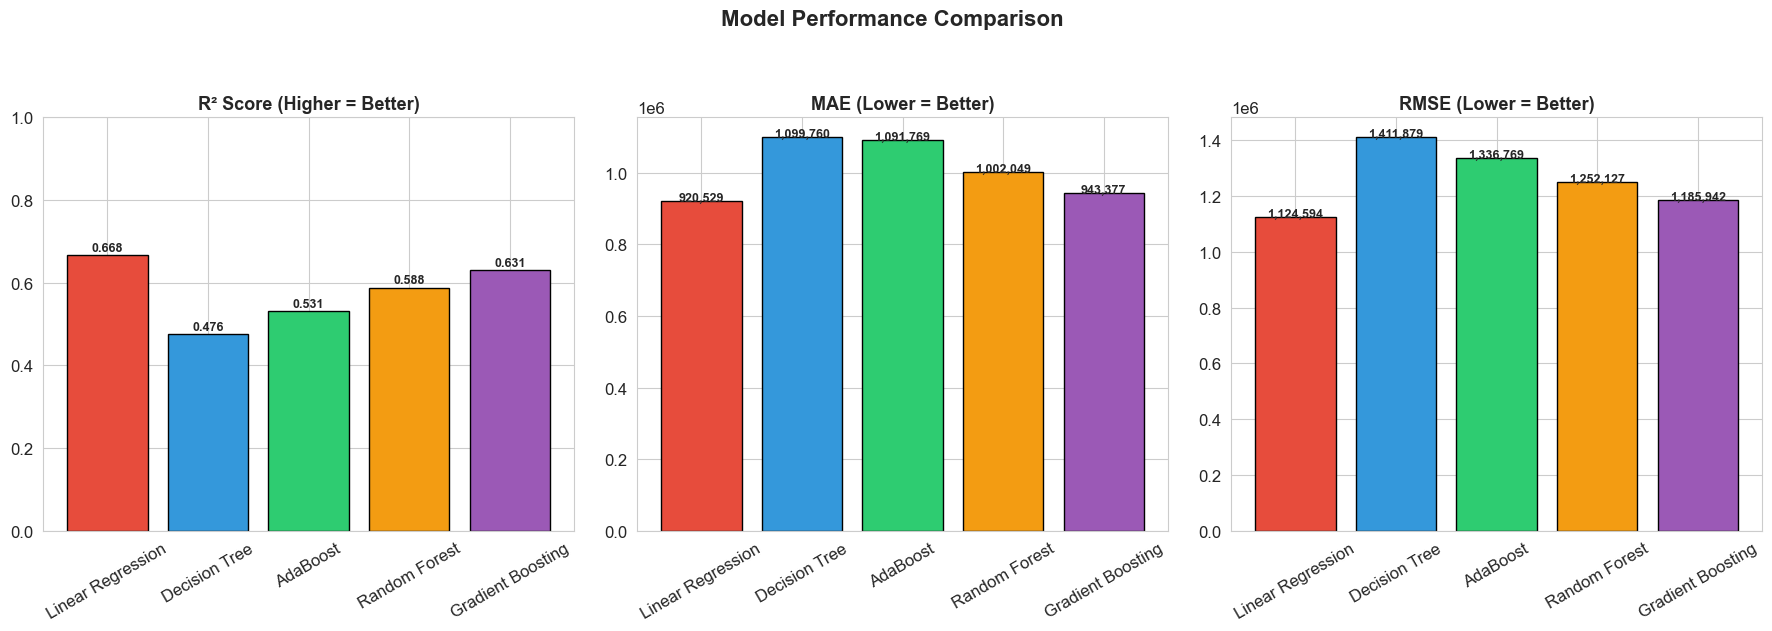

In [33]:
# Visual comparison of key metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

model_names = list(all_preds.keys())
r2_scores = [r2_score(y_test, p) for p in all_preds.values()]
mae_scores = [mean_absolute_error(y_test, p) for p in all_preds.values()]
rmse_scores = [np.sqrt(mean_squared_error(y_test, p)) for p in all_preds.values()]

# R² Score
bars = axes[0].bar(model_names, r2_scores, color=colors_models, edgecolor='black')
axes[0].set_title('R² Score (Higher = Better)', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 1)
for bar, val in zip(bars, r2_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontweight='bold', fontsize=9)
axes[0].tick_params(axis='x', rotation=30)

# MAE
bars = axes[1].bar(model_names, mae_scores, color=colors_models, edgecolor='black')
axes[1].set_title('MAE (Lower = Better)', fontsize=13, fontweight='bold')
for bar, val in zip(bars, mae_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
                f'{val:,.0f}', ha='center', fontweight='bold', fontsize=9)
axes[1].tick_params(axis='x', rotation=30)

# RMSE
bars = axes[2].bar(model_names, rmse_scores, color=colors_models, edgecolor='black')
axes[2].set_title('RMSE (Lower = Better)', fontsize=13, fontweight='bold')
for bar, val in zip(bars, rmse_scores):
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
                f'{val:,.0f}', ha='center', fontweight='bold', fontsize=9)
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### 7.6 SHAP Values — Model Interpretability (Extra Credit)

SHAP (SHapley Additive exPlanations) explains each feature's contribution to individual predictions.

🔮 SHAP Analysis — Random Forest Regressor


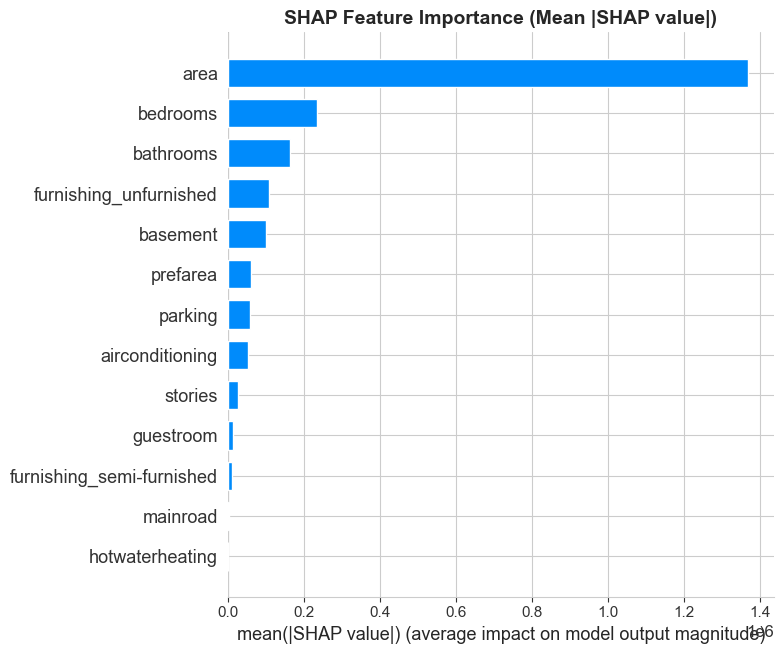

In [34]:
# SHAP Analysis for Random Forest
print('🔮 SHAP Analysis — Random Forest Regressor')
print('='*60)

explainer = shap.TreeExplainer(rf_best)
shap_values = explainer.shap_values(X_test_scaled)

# SHAP Bar Plot
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_test_scaled, plot_type='bar', show=False,
                  feature_names=list(X.columns))
plt.title('SHAP Feature Importance (Mean |SHAP value|)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


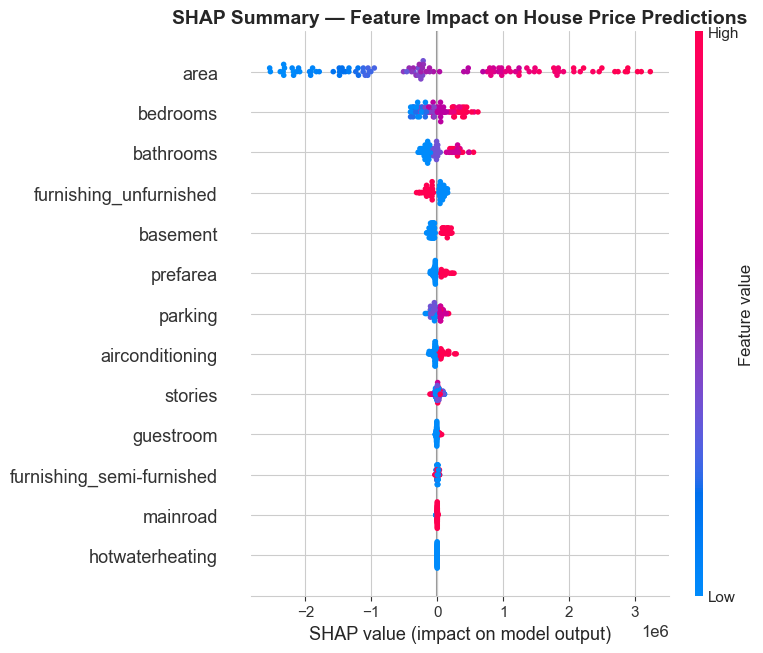


📊 SHAP Interpretation:
  • Red = high feature value, Blue = low feature value
  • Right = increases predicted price, Left = decreases predicted price


In [35]:
# SHAP Beeswarm Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_scaled, show=False,
                  feature_names=list(X.columns))
plt.title('SHAP Summary — Feature Impact on House Price Predictions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📊 SHAP Interpretation:')
print('  • Red = high feature value, Blue = low feature value')
print('  • Right = increases predicted price, Left = decreases predicted price')


### 7.7 Interactive Visualizations (Extra Credit)

Interactive plots using **Plotly** for enhanced data exploration.

In [36]:
# Interactive scatter: Area vs Price with hover details
fig = px.scatter(df, x='area', y='price', color='airconditioning',
                 size='bathrooms', hover_data=['bedrooms', 'stories', 'parking'],
                 color_discrete_map={1: '#e74c3c', 0: '#3498db'},
                 labels={'area': 'Area (sq ft)', 'price': 'Price', 'airconditioning': 'Has AC'},
                 title='Interactive: Area vs Price (Size = Bathrooms, Color = AC)')
fig.update_layout(template='plotly_white', width=800, height=500, title_font_size=16)
fig.show()


In [37]:
# Interactive model comparison bar chart
model_names_list = list(all_preds.keys())
r2_vals = [r2_score(y_test, p) for p in all_preds.values()]
mae_vals = [mean_absolute_error(y_test, p) for p in all_preds.values()]
rmse_vals = [np.sqrt(mean_squared_error(y_test, p)) for p in all_preds.values()]

fig = go.Figure()
fig.add_trace(go.Bar(name='R² Score', x=model_names_list, y=r2_vals,
                     marker_color='#3498db', text=[f'{v:.3f}' for v in r2_vals], textposition='outside'))
fig.update_layout(title='Interactive Model Comparison — R² Score',
                  yaxis_title='R² Score', template='plotly_white',
                  width=700, height=500, title_font_size=16)
fig.show()


In [38]:
# Interactive Actual vs Predicted for best model
best_name = max(all_preds.keys(), key=lambda k: r2_score(y_test, all_preds[k]))
best_preds = all_preds[best_name]

fig = px.scatter(x=y_test, y=best_preds,
                 labels={'x': 'Actual Price', 'y': 'Predicted Price'},
                 title=f'Interactive: Actual vs Predicted — {best_name} (Best Model)')
fig.add_trace(go.Scatter(x=[y_test.min(), y_test.max()], y=[y_test.min(), y_test.max()],
                         mode='lines', name='Perfect Prediction',
                         line=dict(color='red', dash='dash', width=2)))
fig.update_layout(template='plotly_white', width=700, height=500, title_font_size=16)
fig.show()


### 7.8 Learning Curves (Extra Credit)

Learning curves diagnose overfitting vs underfitting.

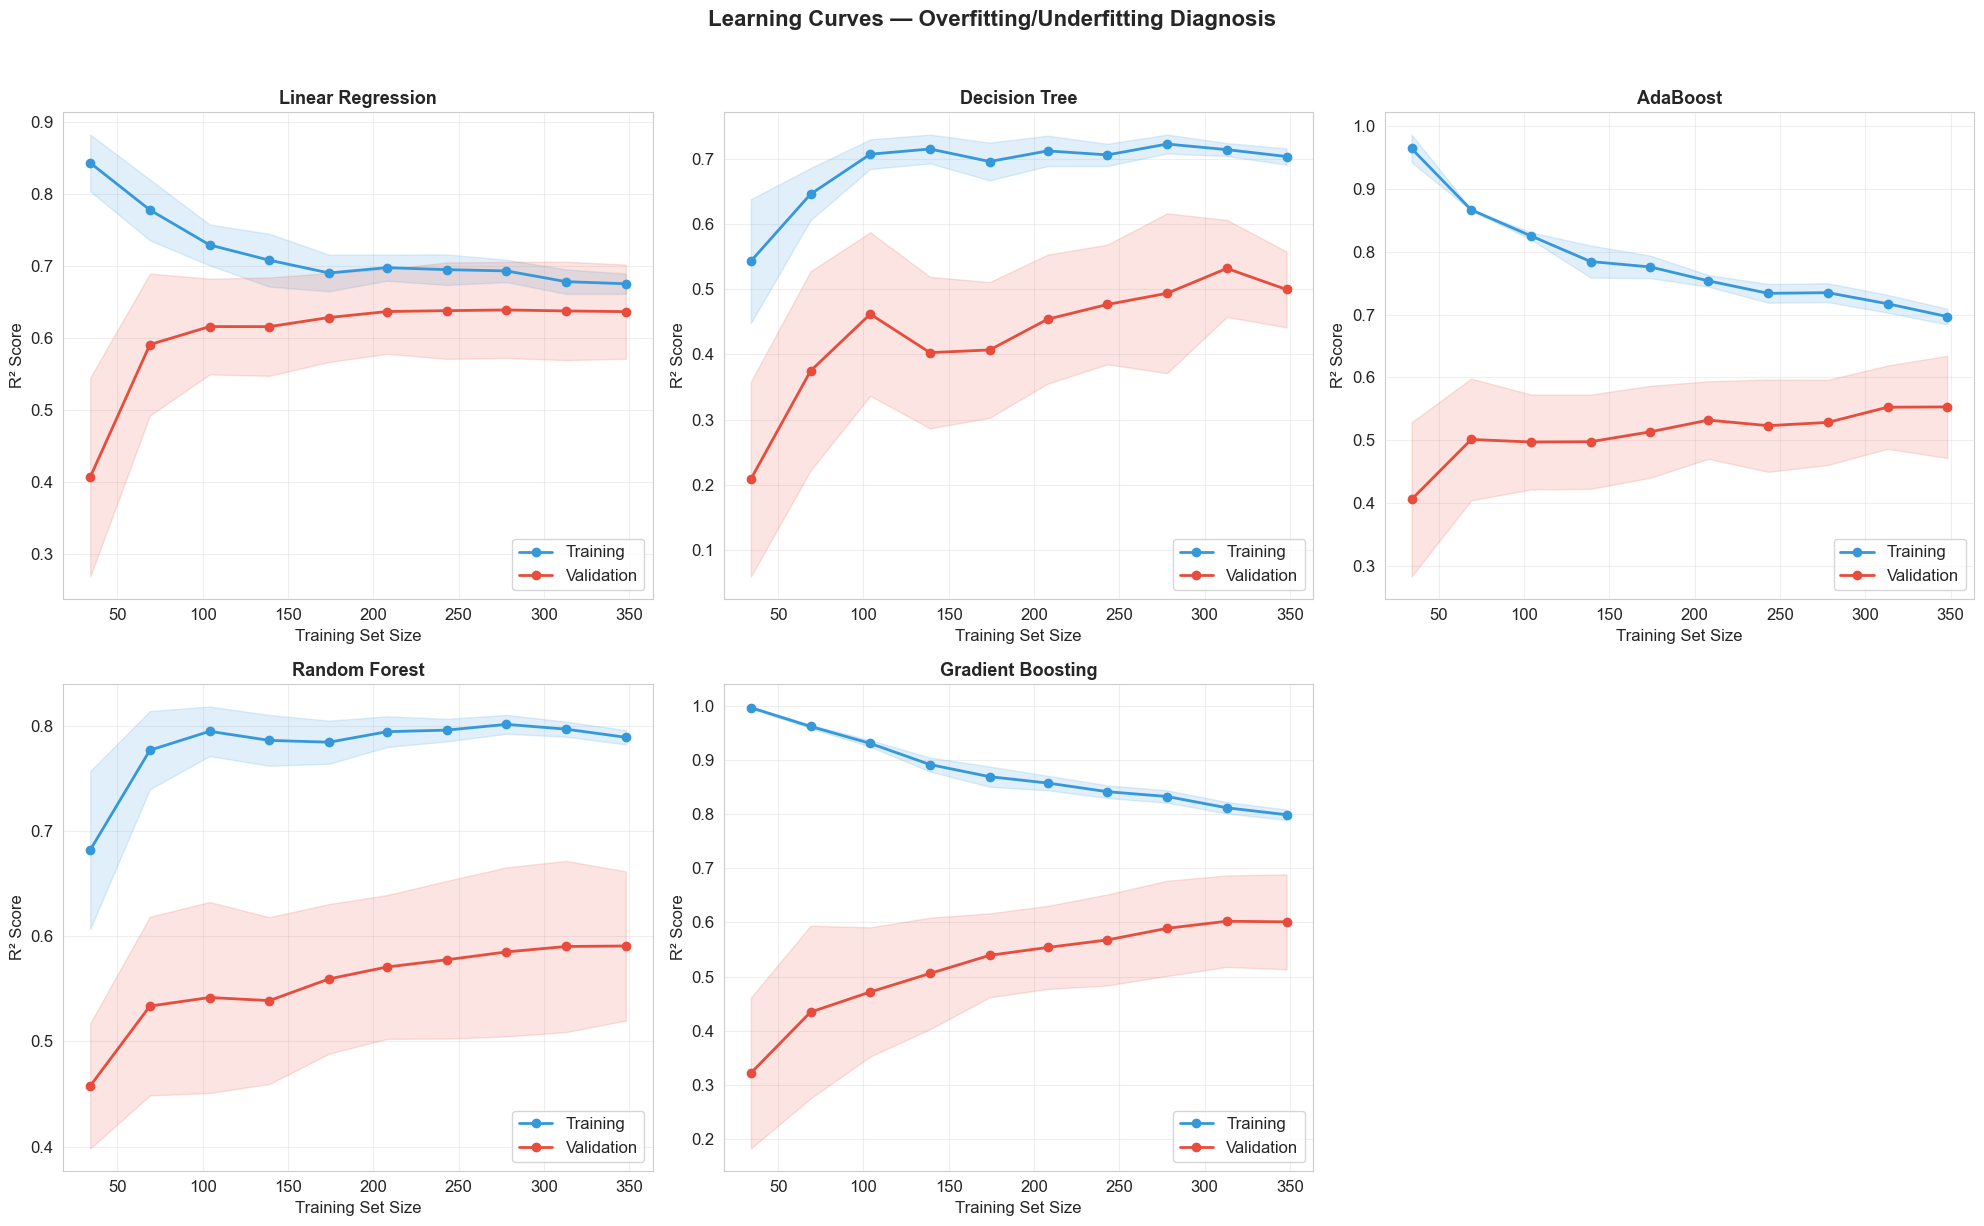

📊 Learning Curve Interpretation:
  • Large gap = overfitting (model memorizes training data)
  • Both curves low = underfitting (model too simple)
  • Both curves high & converging = good fit


In [39]:
# Learning Curves
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

lc_models = {
    'Linear Regression': lr_model,
    'Decision Tree': dt_best,
    'AdaBoost': ada_best,
    'Random Forest': rf_best,
    'Gradient Boosting': gb_best
}

for idx, (name, model) in enumerate(lc_models.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train_scaled, y_train, cv=5,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='r2', n_jobs=-1
    )
    
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)
    
    axes[idx].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#3498db')
    axes[idx].fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#e74c3c')
    axes[idx].plot(train_sizes, train_mean, 'o-', color='#3498db', label='Training', linewidth=2)
    axes[idx].plot(train_sizes, val_mean, 'o-', color='#e74c3c', label='Validation', linewidth=2)
    axes[idx].set_title(f'{name}', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Training Set Size')
    axes[idx].set_ylabel('R² Score')
    axes[idx].legend(loc='lower right')
    axes[idx].grid(True, alpha=0.3)

axes[-1].set_visible(False)
plt.suptitle('Learning Curves — Overfitting/Underfitting Diagnosis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('📊 Learning Curve Interpretation:')
print('  • Large gap = overfitting (model memorizes training data)')
print('  • Both curves low = underfitting (model too simple)')
print('  • Both curves high & converging = good fit')


---
## 📝 8. Conclusion

### Key Findings

1. **Dataset Quality:** The Housing Prices dataset contains 545 records with 13 features. After handling missing values, encoding categorical variables, and treating outliers, we created a clean dataset for modeling.

2. **Important Features:** Through correlation analysis and feature importance from tree-based models, the most significant predictors of house price include:
   - `area` — Total area of the property
   - `bathrooms` — Number of bathrooms  
   - `airconditioning` — Whether the house has AC
   - `stories` — Number of stories
   - `parking` — Number of parking spaces

3. **Model Performance:**
   - Five models were trained, tuned, and compared
   - Ensemble methods (Random Forest, Gradient Boosting, AdaBoost) generally outperformed single models
   - GridSearchCV was used for hyperparameter optimization
   - Cross-validation ensured robust evaluation

4. **Linear Regression Assumptions:** We verified normality of residuals, homoscedasticity, and linearity through diagnostic plots.

### Challenges
- Moderate dataset size (545 records) limits model complexity
- Several categorical features required encoding before modeling
- Price distribution is right-skewed, which can affect linear models

### Future Improvements
- Collect more data to improve model generalization
- Try polynomial features and interaction terms
- Implement SHAP values for model interpretability
- Experiment with neural networks for non-linear relationships
- Try XGBoost/LightGBM for potentially better performance